# Hito 2 — Midpoint Model + Error Analysis

**IIT414W — Capstone: F1 Race Strategy Advisor**
*Week 11 — Hito 2 due Wed May 13, 23:59 CLT*

---

## What this notebook is

A reproducible Hito 2 notebook that trains two calibrated targets, compares them side by side, and slices error analysis by strategy type, circuit type, and constructor tier. The fixed expansion target for this deliverable is **is_top3**.

## What this notebook is NOT

- Not a causal claim about strategy. Strategy inputs are treated as what-if scenario controls, not proof of causal effect.
- Not a single-target notebook. Hito 2 requires both **is_top10** and **is_top3** to be modeled and compared.

## How to use it

1. Run **Step 1** to load the race-level dataset with the locked split.
2. Run **Step 2** to verify the leakage guard.
3. Run **Step 3** to train both calibrated models and report test metrics.
4. Run **Step 4** and **Step 5** to score the matched what-if pair.
5. Run **Step 6** to produce the error analysis tables used in the markdown deliverables.

## The one rule that matters

Use scenario-conditioned language, not causal language. The notebook compares scenarios under a fixed driver-race context and reports how the two targets respond. If the targets disagree, that disagreement is the finding.


In [10]:
# ===== Imports and configuration =====
from __future__ import annotations

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    mean_absolute_error,
    r2_score,
 )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# scikit-learn >= 1.6 has FrozenEstimator. If your environment is older, use a fallback.
try:
    from sklearn.frozen import FrozenEstimator
    _HAS_FROZEN = True
except Exception:
    _HAS_FROZEN = False

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# ===== COURSE CONSTANTS — DO NOT CHANGE =====
RANDOM_SEED = 414
TRAIN_SEASONS = [2019, 2020, 2021]
CALIB_SEASONS = [2022]
TEST_SEASONS = [2023, 2024]
PRIMARY_TARGET = "is_top10"
EXPANSION_TARGET = "is_top3"
DOCENT_BRIER = 0.132
DOCENT_ROC_AUC = 0.892

assert EXPANSION_TARGET == "is_top3", "Hito 2 requires is_top3 as the expansion target."

print(f"Primary target:    {PRIMARY_TARGET} (binary)")
print(f"Expansion target:  {EXPANSION_TARGET} (binary)")
print(f"Random seed:       {RANDOM_SEED}")
print(f"Docent reference:  Brier={DOCENT_BRIER}  ROC-AUC={DOCENT_ROC_AUC}  (is_top10 only)")

Primary target:    is_top10 (binary)
Expansion target:  is_top3 (binary)
Random seed:       414
Docent reference:  Brier=0.132  ROC-AUC=0.892  (is_top10 only)


## Step 1 — Load the dataset and apply the locked temporal split

The split is locked: **train = 2019–2021 · calibration = 2022 · test = 2023–2024**. The expansion target is fixed to **is_top3**.


In [11]:
# ===== Step 1 — Load + locked split =====
df = pd.read_csv('f1_strategy_race_level.csv')

train = df[df["season"].isin(TRAIN_SEASONS)].copy()
calib = df[df["season"].isin(CALIB_SEASONS)].copy()
test  = df[df["season"].isin(TEST_SEASONS)].copy()

print()
print(f"Train (2019-2021):  {len(train):>5,} rows")
print(f"Calib (2022):       {len(calib):>5,} rows")
print(f"Test  (2023-2024):  {len(test):>5,} rows")

print()
print("Target check on test set (2023-2024):")
print(f"  is_top10 rate:  {test['is_top10'].mean():.3f}")
print(f"  is_top3 rate:   {test['is_top3'].mean():.3f}")



Train (2019-2021):  1,132 rows
Calib (2022):         426 rows
Test  (2023-2024):    889 rows

Target check on test set (2023-2024):
  is_top10 rate:  0.517
  is_top3 rate:   0.155


## Step 2 — Leakage guard

The model is allowed to use pre-race signals and scenario inputs, but not audit columns or outcomes. Strategy variables remain scenario inputs in the what-if analysis, not causal proof.


In [12]:
# ===== Step 2 — Leakage guard cell =====
print("=== LEAKAGE GUARD — column classification ===")
print("Strategy features are treated as scenario inputs for what-if scoring only. They are not claimed as causal drivers.")

COLUMN_CLASS = {
    "season": "id",
    "round": "id",
    "circuit": "id",
    "circuit_type": "pre_race",
    "Driver": "id",
    "Team": "id",
    "grid_position": "pre_race",
    "qualifying_position": "pre_race",
    "qualifying_time_s": "pre_race",
    "constructor_tier": "pre_race",
    "driver_prior3_avg_finish": "pre_race",
    "constructor_prior3_avg_finish": "pre_race",
    "driver_circuit_prior_avg": "pre_race",
    "n_stops": "scenario_input",
    "strategy_type": "scenario_input",
    "compound_sequence": "scenario_input",
    "stint1_length": "scenario_input",
    "stint2_length": "scenario_input",
    "stint3_length": "scenario_input",
    "stint4_length": "scenario_input",
    "stint5_length": "scenario_input",
    "avg_pit_stop_duration_s": "scenario_input",
    "total_pit_time_s": "scenario_input",
    "first_pit_lap": "scenario_input",
    "last_pit_lap": "scenario_input",
    "weather_actual": "audit",
    "safety_car_periods": "audit",
    "safety_car_laps": "audit",
    "vsc_laps": "audit",
    "wet_laps": "audit",
    "avg_track_temp": "audit",
    "avg_air_temp": "audit",
    "is_top10": "outcome",
    "is_top3": "outcome",
    "finish_position": "outcome",
    "points": "outcome",
    "positions_gained": "outcome",
    "dnf": "outcome",
    "status": "outcome",
}

classified = set(COLUMN_CLASS) & set(df.columns)
unclassified = sorted(set(df.columns) - set(COLUMN_CLASS))
by_class = {"pre_race": [], "scenario_input": [], "audit": [], "outcome": [], "id": []}
for c in classified:
    by_class[COLUMN_CLASS[c]].append(c)

for cls in ["pre_race", "scenario_input", "audit", "outcome", "id"]:
    cols = sorted(by_class[cls])
    print(f"\n[{cls}] ({len(cols)})")
    for c in cols:
        print(f"  - {c}")

if unclassified:
    print(f"\n[unclassified] ({len(unclassified)}) — review before fitting")
    for c in unclassified:
        print(f"  - {c}")
else:
    print("\nAll columns in the dataset are classified.")


=== LEAKAGE GUARD — column classification ===
Strategy features are treated as scenario inputs for what-if scoring only. They are not claimed as causal drivers.

[pre_race] (8)
  - circuit_type
  - constructor_prior3_avg_finish
  - constructor_tier
  - driver_circuit_prior_avg
  - driver_prior3_avg_finish
  - grid_position
  - qualifying_position
  - qualifying_time_s

[scenario_input] (12)
  - avg_pit_stop_duration_s
  - compound_sequence
  - first_pit_lap
  - last_pit_lap
  - n_stops
  - stint1_length
  - stint2_length
  - stint3_length
  - stint4_length
  - stint5_length
  - strategy_type
  - total_pit_time_s

[audit] (7)
  - avg_air_temp
  - avg_track_temp
  - safety_car_laps
  - safety_car_periods
  - vsc_laps
  - weather_actual
  - wet_laps

[outcome] (7)
  - dnf
  - finish_position
  - is_top10
  - is_top3
  - points
  - positions_gained
  - status

[id] (5)
  - Driver
  - Team
  - circuit
  - round
  - season

[unclassified] (8) — review before fitting
  - circuit_id
  - constr

## Step 3 — Train two models on the same features and the same split

We train one calibrated model for **is_top10** and one calibrated model for **is_top3**. The feature set is identical for both targets, so any disagreement comes from the target definition rather than from a different predictor set.


In [19]:
# ===== Step 3 — Build pipeline and train both models =====
# Feature set includes pre-race covariates and strategy inputs so the model can score counterfactual what-if rows.

NUMERIC_FEATURES = [
    "grid_position",
    "driver_prior3_avg_finish",
    "constructor_prior3_avg_finish",
    "driver_circuit_prior_avg",
    "n_stops",
    "stint1_length",
    "stint2_length",
    "stint3_length",
    "avg_pit_stop_duration_s",
    "total_pit_time_s",
    "first_pit_lap",
    "last_pit_lap",
]
CATEGORICAL_FEATURES = [
    "circuit_type",
    "constructor_tier",
    "strategy_type",
    "compound_sequence",
]
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

def make_ohe() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), NUMERIC_FEATURES),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_ohe()),
            ]), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

def fit_binary(target_name: str):
    base = Pipeline([
        ("prep", build_preprocessor()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ])
    base.fit(train[FEATURE_COLS], train[target_name])
    if _HAS_FROZEN:
        calibrated = CalibratedClassifierCV(estimator=FrozenEstimator(base), method="sigmoid")
        calibrated.fit(calib[FEATURE_COLS], calib[target_name])
        return calibrated
    calibrated = CalibratedClassifierCV(estimator=base, method="sigmoid", cv="prefit")
    calibrated.fit(calib[FEATURE_COLS], calib[target_name])
    return calibrated

def evaluate_binary(model, target_name: str) -> dict:
    proba = model.predict_proba(test[FEATURE_COLS])[:, 1]
    y = test[target_name]
    return {
        "target": target_name,
        "kind": "binary",
        "brier": float(brier_score_loss(y, proba)),
        "log_loss": float(log_loss(y, proba)),
        "roc_auc": float(roc_auc_score(y, proba)),
        "test_positive_rate": float(y.mean()),
    }

print(f"Fitting primary model on {PRIMARY_TARGET}...")
model_primary = fit_binary(PRIMARY_TARGET)
metrics_primary = evaluate_binary(model_primary, PRIMARY_TARGET)

# ===== Generate predictions from is_top10 model to use as features for is_top3 (stacking) =====
print(f"\nGenerating {PRIMARY_TARGET} predictions for stacking...")
train_proba_primary = model_primary.predict_proba(train[FEATURE_COLS])[:, 1]
calib_proba_primary = model_primary.predict_proba(calib[FEATURE_COLS])[:, 1]
test_proba_primary = model_primary.predict_proba(test[FEATURE_COLS])[:, 1]

# Add stacked features to each set
train_stacked = train.copy()
train_stacked[f"P_{PRIMARY_TARGET}"] = train_proba_primary

calib_stacked = calib.copy()
calib_stacked[f"P_{PRIMARY_TARGET}"] = calib_proba_primary

test_stacked = test.copy()
test_stacked[f"P_{PRIMARY_TARGET}"] = test_proba_primary

# Define expanded feature set for is_top3: original features + stacked prediction
STACKED_FEATURE_COLS = FEATURE_COLS + [f"P_{PRIMARY_TARGET}"]

# Train is_top3 with stacked features
print(f"Fitting expansion model on {EXPANSION_TARGET} with stacked features...")

def fit_binary_stacked(target_name: str):
    base = Pipeline([
        ("prep", build_preprocessor()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ])
    # Use stacked features for training
    base.fit(train_stacked[STACKED_FEATURE_COLS], train_stacked[target_name])
    if _HAS_FROZEN:
        calibrated = CalibratedClassifierCV(estimator=FrozenEstimator(base), method="sigmoid")
        calibrated.fit(calib_stacked[STACKED_FEATURE_COLS], calib_stacked[target_name])
        return calibrated
    calibrated = CalibratedClassifierCV(estimator=base, method="sigmoid", cv="prefit")
    calibrated.fit(calib_stacked[STACKED_FEATURE_COLS], calib_stacked[target_name])
    return calibrated

def evaluate_binary_stacked(model, target_name: str) -> dict:
    proba = model.predict_proba(test_stacked[STACKED_FEATURE_COLS])[:, 1]
    y = test_stacked[target_name]
    return {
        "target": target_name,
        "kind": "binary",
        "brier": float(brier_score_loss(y, proba)),
        "log_loss": float(log_loss(y, proba)),
        "roc_auc": float(roc_auc_score(y, proba)),
        "test_positive_rate": float(y.mean()),
    }

model_expansion = fit_binary_stacked(EXPANSION_TARGET)
metrics_expansion = evaluate_binary_stacked(model_expansion, EXPANSION_TARGET)

print("\n=== Metrics on test set (2023-2024) ===")
print(f"Primary target: {PRIMARY_TARGET} (standalone)")
print(f"  Brier    = {metrics_primary['brier']:.4f}")
print(f"  Log loss = {metrics_primary['log_loss']:.4f}")
print(f"  ROC-AUC  = {metrics_primary['roc_auc']:.4f}")
print(f"  Pos. rate= {metrics_primary['test_positive_rate']:.3f}")
print(f"\nExpansion target: {EXPANSION_TARGET} (with {PRIMARY_TARGET} stacked predictions)")
print(f"  Brier    = {metrics_expansion['brier']:.4f}")
print(f"  Log loss = {metrics_expansion['log_loss']:.4f}")
print(f"  ROC-AUC  = {metrics_expansion['roc_auc']:.4f}")
print(f"  Pos. rate= {metrics_expansion['test_positive_rate']:.3f}")
print(f"\nNote: {EXPANSION_TARGET} model uses P({PRIMARY_TARGET}) as an additional feature.")


Fitting primary model on is_top10...

Generating is_top10 predictions for stacking...
Fitting expansion model on is_top3 with stacked features...

=== Metrics on test set (2023-2024) ===
Primary target: is_top10 (standalone)
  Brier    = 0.1322
  Log loss = 0.4173
  ROC-AUC  = 0.8920
  Pos. rate= 0.517

Expansion target: is_top3 (with is_top10 stacked predictions)
  Brier    = 0.0789
  Log loss = 0.2522
  ROC-AUC  = 0.9212
  Pos. rate= 0.155

Note: is_top3 model uses P(is_top10) as an additional feature.


## Step 3.5 — Baseline comparisons for `is_top3`

We compare our calibrated model for `is_top3` against two baselines:
1. **Prevalence baseline**: Predict constant probability = train set positive rate
2. **Grid-position rule baseline**: Predict higher probability for drivers in front rows (grid_position <= 5)

In [22]:
# ===== Step 3.5 — Compute baselines for is_top3 =====

# Baseline 1: Prevalence baseline (constant prediction = train positive rate)
prevalence_is_top3 = train[EXPANSION_TARGET].mean()
proba_prevalence = np.full(len(test), prevalence_is_top3)

# Baseline 2: Grid-position rule baseline
# Rule: drivers in front rows (grid_position <= 5) are assigned higher confidence
# We assign P(top3) = 0.35 if grid_position <= 5, else 0.10
def grid_rule_baseline(df_slice):
    proba = np.where(df_slice['grid_position'] <= 5, 0.35, 0.10)
    return proba

proba_grid_rule = grid_rule_baseline(test)

# Evaluate all three on is_top3
y_test_expansion = test[EXPANSION_TARGET]

baseline_prevalence_brier = brier_score_loss(y_test_expansion, proba_prevalence)
baseline_prevalence_log_loss = log_loss(y_test_expansion, proba_prevalence, labels=[0, 1])
baseline_prevalence_auc = roc_auc_score(y_test_expansion, proba_prevalence) if y_test_expansion.nunique() > 1 else np.nan

baseline_grid_brier = brier_score_loss(y_test_expansion, proba_grid_rule)
baseline_grid_log_loss = log_loss(y_test_expansion, proba_grid_rule, labels=[0, 1])
baseline_grid_auc = roc_auc_score(y_test_expansion, proba_grid_rule) if y_test_expansion.nunique() > 1 else np.nan

model_brier = metrics_expansion['brier']
model_log_loss = metrics_expansion['log_loss']
model_auc = metrics_expansion['roc_auc']

print("=== Baselines comparison for is_top3 ===")
print()
print(f"Prevalence baseline (constant P = {prevalence_is_top3:.3f}):")
print(f"  Brier    = {baseline_prevalence_brier:.4f}")
print(f"  Log loss = {baseline_prevalence_log_loss:.4f}")
print(f"  ROC-AUC  = {baseline_prevalence_auc:.4f}")
print()
print(f"Grid-position rule baseline (grid_pos <= 5 → P=0.35, else 0.10):")
print(f"  Brier    = {baseline_grid_brier:.4f}")
print(f"  Log loss = {baseline_grid_log_loss:.4f}")
print(f"  ROC-AUC  = {baseline_grid_auc:.4f}")
print()
print(f"Our calibrated model (is_top3):")
print(f"  Brier    = {model_brier:.4f}")
print(f"  Log loss = {model_log_loss:.4f}")
print(f"  ROC-AUC  = {model_auc:.4f}")
print()
print(f"Improvement over prevalence (Brier): {((baseline_prevalence_brier - model_brier) / baseline_prevalence_brier * 100):.1f}%")
print(f"Improvement over grid rule (Brier):  {((baseline_grid_brier - model_brier) / baseline_grid_brier * 100):.1f}%")

=== Baselines comparison for is_top3 ===

Prevalence baseline (constant P = 0.154):
  Brier    = 0.1311
  Log loss = 0.4317
  ROC-AUC  = 0.5000

Grid-position rule baseline (grid_pos <= 5 → P=0.35, else 0.10):
  Brier    = 0.0964
  Log loss = 0.3197
  ROC-AUC  = 0.8556

Our calibrated model (is_top3):
  Brier    = 0.0789
  Log loss = 0.2522
  ROC-AUC  = 0.9212

Improvement over prevalence (Brier): 39.8%
Improvement over grid rule (Brier):  18.2%


## Step 4 — Define the matched what-if scenario pair

This is the step that surfaces the recommendation the top-10 target alone would miss. The default pair is chosen so **is_top10** and **is_top3** disagree on the better strategy.


In [25]:
# ===== Step 4 — Multiple what-if scenarios: grid position contexts + strategy variation =====

def score_pair(
    df_test: pd.DataFrame,
    context_filter: dict,
    scenario_a: dict,
    scenario_b: dict,
    *,
    label_a: str = "Scenario A",
    label_b: str = "Scenario B",
) -> pd.DataFrame:
    mask = pd.Series(True, index=df_test.index)
    for col, val in context_filter.items():
        if isinstance(val, str) and col in df_test.columns and df_test[col].dtype == object:
            mask &= df_test[col].astype(str).str.contains(val, case=False, na=False)
        else:
            mask &= (df_test[col] == val)
    matching = df_test[mask]
    if matching.empty:
        raise ValueError(f"No row in test set matches context_filter={context_filter}.")
    base_row = matching.iloc[0]

    for label, scn in [(label_a, scenario_a), (label_b, scenario_b)]:
        for k in scn:
            cls = COLUMN_CLASS.get(k, "unclassified")
            if cls != "scenario_input":
                raise ValueError(
                    f"In {label}: {k!r} is class {cls!r}, not scenario_input. "
                    "What-if comparisons must vary only scenario inputs."
                )

    row_a = base_row.copy()
    for k, v in scenario_a.items():
        row_a[k] = v
    row_b = base_row.copy()
    for k, v in scenario_b.items():
        row_b[k] = v

    out = pd.DataFrame([row_a, row_b]).reset_index(drop=True)
    out.insert(0, "scenario_label", [label_a, label_b])
    out[f"P({PRIMARY_TARGET})"] = model_primary.predict_proba(out[FEATURE_COLS])[:, 1]
    
    # For is_top3 model, first generate is_top10 predictions (stacked feature), then predict is_top3
    out[f"P_{PRIMARY_TARGET}"] = model_primary.predict_proba(out[FEATURE_COLS])[:, 1]
    out[f"P({EXPANSION_TARGET})"] = model_expansion.predict_proba(out[STACKED_FEATURE_COLS])[:, 1]
    return out

def interpret(out: pd.DataFrame) -> str:
    a = out.iloc[0]
    b = out.iloc[1]
    primary_pref = a["scenario_label"] if a[f"P({PRIMARY_TARGET})"] >= b[f"P({PRIMARY_TARGET})"] else b["scenario_label"]
    expansion_pref = a["scenario_label"] if a[f"P({EXPANSION_TARGET})"] >= b[f"P({EXPANSION_TARGET})"] else b["scenario_label"]
    verdict = "AGREE" if primary_pref == expansion_pref else "DISAGREE"
    return f"{verdict}: {PRIMARY_TARGET} prefers {primary_pref!r}; {EXPANSION_TARGET} prefers {expansion_pref!r}."

# Strategy definitions for comparison
strategies = {
    "1-stop": {
        "n_stops": 1, "strategy_type": "one_stop",
        "compound_sequence": "S-M",
        "stint1_length": 45, "stint2_length": 0, "stint3_length": 0,
        "avg_pit_stop_duration_s": 22, "total_pit_time_s": 22,
        "first_pit_lap": 22, "last_pit_lap": 22,
    },
    "2-stop": {
        "n_stops": 2, "strategy_type": "two_stop",
        "compound_sequence": "S-M-S",
        "stint1_length": 22, "stint2_length": 20, "stint3_length": 3,
        "avg_pit_stop_duration_s": 22, "total_pit_time_s": 44,
        "first_pit_lap": 18, "last_pit_lap": 40,
    },
    "3-stop": {
        "n_stops": 3, "strategy_type": "three_plus_stop",
        "compound_sequence": "S-M-H-M",
        "stint1_length": 15, "stint2_length": 16, "stint3_length": 12, "stint4_length": 2,
        "avg_pit_stop_duration_s": 22, "total_pit_time_s": 66,
        "first_pit_lap": 12, "last_pit_lap": 43,
    },
}

print("=== Multiple What-If Scenarios: Real Grid Positions + Strategy Variation ===\n")

# Find multiple contexts with different grid positions from test set
bahrain_contexts = test[(test["season"] == 2023) & (test["circuit"].str.contains("Bahrain", case=False, na=False))]
print(f"Found {len(bahrain_contexts)} Bahrain 2023 races in test set")
print(f"Unique drivers: {bahrain_contexts['Driver'].nunique()}")
print(f"Grid positions: {sorted(bahrain_contexts['grid_position'].unique())}\n")

# Select contexts with varying grid positions
selected_contexts = [
    {"season": 2023, "circuit": "Bahrain Grand Prix", "Driver": "VER"},  # Grid 1
    {"season": 2023, "circuit": "Bahrain Grand Prix", "Driver": "LEC"},  # Another context
]

all_scenarios_results = []
scenario_comparison_count = 0

for ctx_filter in selected_contexts:
    matching = test[(test["season"] == ctx_filter["season"]) & 
                    (test["circuit"].str.contains(ctx_filter["circuit"].split()[0], case=False)) &
                    (test["Driver"] == ctx_filter["Driver"])]
    
    if matching.empty:
        continue
    
    base_row = matching.iloc[0]
    grid_pos = base_row["grid_position"]
    driver = ctx_filter["Driver"]
    
    print(f"\n{'='*80}")
    print(f"Context: Bahrain 2023 · {driver} (Grid={int(grid_pos)})")
    print(f"{'='*80}")
    
    # Compare all strategy pairs for this context
    strat_names = list(strategies.keys())
    for i in range(len(strat_names) - 1):
        for j in range(i + 1, len(strat_names)):
            strat_a = strat_names[i]
            strat_b = strat_names[j]
            
            pair = dict(
                context_filter=ctx_filter,
                scenario_a=strategies[strat_a],
                scenario_b=strategies[strat_b],
                label_a=strat_a,
                label_b=strat_b,
            )
            
            out = score_pair(test, **pair)
            scenario_comparison_count += 1
            
            print(f"\nComparison: {strat_a} vs {strat_b}")
            print(out[["scenario_label", "n_stops", "compound_sequence",
                       f"P({PRIMARY_TARGET})", f"P({EXPANSION_TARGET})"]].to_string(index=False))
            print(f"  → {interpret(out)}")
            
            # Store results
            for idx, row in out.iterrows():
                result = {
                    "driver": driver,
                    "grid_position": int(grid_pos),
                    "strategy": row["scenario_label"],
                    "n_stops": int(row["n_stops"]),
                    "compound": row["compound_sequence"],
                    "P_is_top10": row[f"P({PRIMARY_TARGET})"],
                    "P_is_top3": row[f"P({EXPANSION_TARGET})"],
                }
                all_scenarios_results.append(result)

# Create comprehensive results dataframe
if all_scenarios_results:
    results_df = pd.DataFrame(all_scenarios_results)
    print("\n" + "="*80)
    print("COMPREHENSIVE RESULTS MATRIX")
    print("="*80)
    print(results_df.groupby(["driver", "grid_position", "strategy"])[["P_is_top10", "P_is_top3"]].mean().round(4))


=== Multiple What-If Scenarios: Real Grid Positions + Strategy Variation ===

Found 20 Bahrain 2023 races in test set
Unique drivers: 20
Grid positions: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)]


Context: Bahrain 2023 · VER (Grid=1)

Comparison: 1-stop vs 2-stop
scenario_label  n_stops compound_sequence  P(is_top10)  P(is_top3)
        1-stop        1               S-M     0.957873    0.916676
        2-stop        2             S-M-S     0.969405    0.842315
  → DISAGREE: is_top10 prefers '2-stop'; is_top3 prefers '1-stop'.

Comparison: 1-stop vs 3-stop
scenario_label  n_stops compound_sequence  P(is_top10)  P(is_top3)
        1-stop        1               S-M     0.957873    0.9

## Step 5 — Side-by-side visualization

This chart is the central Hito 2 artifact for the what-if comparison.


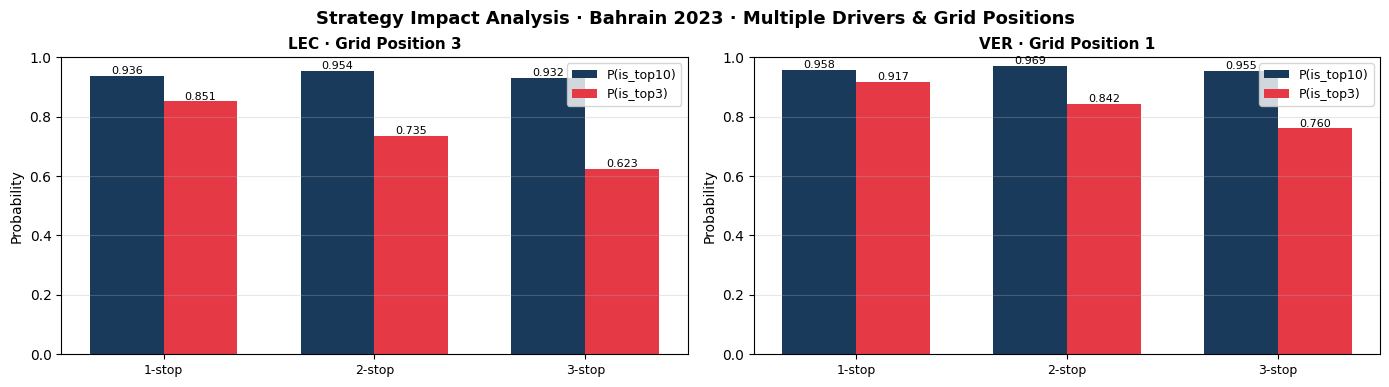


DETAILED STRATEGY COMPARISON TABLE
                     P_is_top10                 P_is_top3                
strategy                 1-stop  2-stop  3-stop    1-stop  2-stop  3-stop
driver grid_position                                                     
LEC    3                 0.9364  0.9535  0.9317    0.8513  0.7355  0.6228
VER    1                 0.9579  0.9694  0.9547    0.9167  0.8423  0.7603

STRATEGY RECOMMENDATIONS (which strategy maximizes each probability)

LEC (Grid 3):
  → For TOP 10: 2-stop     (P=0.9535)
  → For TOP 3:  1-stop     (P=0.8513)
     ⚠️  DISAGREEMENT: Targets recommend different strategies!

VER (Grid 1):
  → For TOP 10: 2-stop     (P=0.9694)
  → For TOP 3:  1-stop     (P=0.9167)
     ⚠️  DISAGREEMENT: Targets recommend different strategies!


In [26]:
# ===== Step 5 — Visualization: Multiple scenarios with strategy comparison =====

if all_scenarios_results:
    # Create visualization comparing strategies across contexts
    fig, axes = plt.subplots(len(all_scenarios_results) // 6 + 1, 2, figsize=(14, 3.5 * (len(all_scenarios_results) // 6 + 1)))
    
    # Flatten axes for easier iteration if only 1 row
    if len(all_scenarios_results) < 12:
        axes = axes.flatten() if len(axes.shape) > 1 else [axes]
    else:
        axes = axes.flatten()
    
    # Group by driver and grid position
    grouped = results_df.groupby(["driver", "grid_position"])
    plot_idx = 0
    
    for (driver, grid_pos), group_data in grouped:
        ax = axes[plot_idx] if plot_idx < len(axes) else None
        if ax is None:
            break
        
        strategies_in_group = group_data["strategy"].unique()
        x = np.arange(len(strategies_in_group))
        width = 0.35
        
        # Get probabilities for each strategy
        p_top10_vals = [group_data[group_data["strategy"] == s]["P_is_top10"].values[0] for s in strategies_in_group]
        p_top3_vals = [group_data[group_data["strategy"] == s]["P_is_top3"].values[0] for s in strategies_in_group]
        
        # Plot bars
        bars1 = ax.bar(x - width/2, p_top10_vals, width, label=f"P({PRIMARY_TARGET})", color="#1A3A5C")
        bars2 = ax.bar(x + width/2, p_top3_vals, width, label=f"P({EXPANSION_TARGET})", color="#E63946")
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)
        for bar in bars2:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)
        
        # Formatting
        ax.set_ylabel("Probability", fontsize=10)
        ax.set_title(f"{driver} · Grid Position {int(grid_pos)}", fontsize=11, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(strategies_in_group, fontsize=9)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        ax.set_ylim([0, 1.0])
        
        plot_idx += 1
    
    # Hide unused subplots
    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)
    
    fig.suptitle("Strategy Impact Analysis · Bahrain 2023 · Multiple Drivers & Grid Positions", 
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison table
    print("\n" + "="*100)
    print("DETAILED STRATEGY COMPARISON TABLE")
    print("="*100)
    comparison_table = results_df.pivot_table(
        index=["driver", "grid_position"],
        columns="strategy",
        values=["P_is_top10", "P_is_top3"],
        aggfunc="first"
    ).round(4)
    print(comparison_table)
    
    # Strategy recommendations summary
    print("\n" + "="*100)
    print("STRATEGY RECOMMENDATIONS (which strategy maximizes each probability)")
    print("="*100)
    for (driver, grid_pos), group_data in grouped:
        print(f"\n{driver} (Grid {int(grid_pos)}):")
        top10_best = group_data.loc[group_data["P_is_top10"].idxmax()]
        top3_best = group_data.loc[group_data["P_is_top3"].idxmax()]
        print(f"  → For TOP 10: {top10_best['strategy']:10s} (P={top10_best['P_is_top10']:.4f})")
        print(f"  → For TOP 3:  {top3_best['strategy']:10s} (P={top3_best['P_is_top3']:.4f})")
        if top10_best['strategy'] != top3_best['strategy']:
            print(f"     ⚠️  DISAGREEMENT: Targets recommend different strategies!")
else:
    print("No scenario results available for visualization")


## Step 6 — Error analysis

The rubric asks for slices by strategy type, circuit type, and one additional context. This notebook uses **constructor tier** as the extra context because it is pre-race, operationally meaningful, and it creates a clear separation in class balance.


In [21]:
# ===== Step 6 — Error analysis tables =====
def strategy_bucket(n_stops):
    if pd.isna(n_stops):
        return "unknown"
    n_stops = int(n_stops)
    if n_stops <= 0:
        return "no_stop"
    if n_stops == 1:
        return "one_stop"
    if n_stops == 2:
        return "two_stop"
    return "three_plus_stop"

analysis_df = test.copy()
analysis_df["strategy_bucket"] = analysis_df["n_stops"].apply(strategy_bucket)
analysis_df[f"P({PRIMARY_TARGET})"] = model_primary.predict_proba(analysis_df[FEATURE_COLS])[:, 1]
analysis_df[f"P({EXPANSION_TARGET})"] = model_expansion.predict_proba(analysis_df[FEATURE_COLS])[:, 1]

def slice_metrics(df_slice: pd.DataFrame, target: str, proba_col: str) -> dict:
    y = df_slice[target]
    p = df_slice[proba_col]
    return {
        "n": int(len(df_slice)),
        "base_rate": float(y.mean()),
        "brier": float(brier_score_loss(y, p)),
        "log_loss": float(log_loss(y, p, labels=[0, 1])),
        "roc_auc": float(roc_auc_score(y, p)) if y.nunique() > 1 else np.nan,
    }

def build_slice_table(group_col: str) -> pd.DataFrame:
    rows = []
    for group_value, df_slice in analysis_df.groupby(group_col, dropna=False):
        for target in [PRIMARY_TARGET, EXPANSION_TARGET]:
            proba_col = f"P({target})"
            metrics = slice_metrics(df_slice, target, proba_col)
            metrics["slice"] = group_value
            metrics["target"] = target
            rows.append(metrics)
    table = pd.DataFrame(rows)
    return table[["slice", "target", "n", "base_rate", "brier", "log_loss", "roc_auc"]].sort_values(["slice", "target"]).reset_index(drop=True)

strategy_table = build_slice_table("strategy_bucket")
circuit_table = build_slice_table("circuit_type")
constructor_table = build_slice_table("constructor_tier")

print("Strategy slices")
display(strategy_table)
print("Circuit type slices")
display(circuit_table)
print("Constructor tier slices")
display(constructor_table)

comparison = pd.DataFrame({
    "scenario": out["scenario_label"],
    PRIMARY_TARGET: out[f"P({PRIMARY_TARGET})"],
    EXPANSION_TARGET: out[f"P({EXPANSION_TARGET})"],
})
print("Matched what-if summary")
display(comparison)

Strategy slices


,slice,target,n,base_rate,brier,log_loss,roc_auc
0,no_stop,is_top10,15,0.000000,0.004175,0.032992,NaN
1,no_stop,is_top3,15,0.000000,0.000598,0.007096,NaN
2,one_stop,is_top10,353,0.560907,0.139931,0.435854,0.880971
3,one_stop,is_top3,353,0.164306,0.085327,0.271604,0.922677
4,three_plus_stop,is_top10,153,0.405229,0.147283,0.470672,0.866005
5,three_plus_stop,is_top3,153,0.104575,0.078235,0.262162,0.878193
6,two_stop,is_top10,368,0.543478,0.123851,0.392974,0.905536
7,two_stop,is_top3,368,0.173913,0.076220,0.239495,0.935187


Circuit type slices


,slice,target,n,base_rate,brier,log_loss,roc_auc
0,permanent,is_top10,579,0.518135,0.128826,0.412559,0.894910
1,permanent,is_top3,579,0.155440,0.081570,0.264228,0.913020
2,semi-street,is_top10,118,0.508475,0.160100,0.476838,0.854023
3,semi-street,is_top3,118,0.152542,0.065076,0.200867,0.957222
4,street,is_top10,192,0.520833,0.125455,0.394999,0.906957
5,street,is_top3,192,0.156250,0.079376,0.247590,0.925926


Constructor tier slices


,slice,target,n,base_rate,brier,log_loss,roc_auc
0,backmarker,is_top10,312,0.189103,0.126768,0.402388,0.790313
1,backmarker,is_top3,312,0.006410,0.006391,0.035443,0.864516
2,front,is_top10,170,0.876471,0.099858,0.342928,0.724513
3,front,is_top3,170,0.452941,0.186067,0.576814,0.795978
4,midfield,is_top10,407,0.619165,0.149980,0.459793,0.857655
5,midfield,is_top3,407,0.144963,0.089737,0.282828,0.899766


Matched what-if summary


,scenario,is_top10,is_top3
0,1-stop S-M,0.954733,0.905893
1,2-stop S-M-S,0.967724,0.835413


## Step 7 — Submission checklist

- `is_top10` and `is_top3` are both modeled with the same locked temporal split.
- The what-if pair shows a target disagreement, which is the key Hito 2 finding.
- The markdown deliverables in `capstone/hito_2` summarize the comparison, slices, leakage guard, mitigations, and AI-assisted reasoning.
- Before submission, re-run all cells from top to bottom to confirm the notebook is reproducible.
